### Загрузка необходимых файлов и библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('../data/dataset_2_1.csv',  index_col=0)
df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
0,Алтайский край,2000,31.0,0.377989,17660.5,122.0,52.8,569.0,109.2,2641.1
1,Алтайский край,2001,34.0,0.180408,23509.0,104.5,53.1,599.0,109.4,2621.1
2,Алтайский край,2002,36.0,0.092283,27991.2,103.1,53.2,563.0,100.1,2602.6
3,Алтайский край,2003,36.0,0.056477,34295.8,100.8,53.5,516.0,105.5,2572.0
4,Алтайский край,2004,36.0,0.033324,44934.9,99.5,53.7,488.0,102.6,2539.4


In [3]:
# Смотрим размер датасета
df.shape

(1968, 10)

In [4]:
df.describe()

,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
count,1968.000000,1968.000000,1884.000000,1.968000e+03,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000
mean,2011.500000,189.902536,0.782505,4.168486e+05,102.258816,70.151067,691.476479,105.083659,1746.569766
std,6.923946,266.510499,1.143861,8.511817e+05,10.717656,12.567786,941.456301,10.074794,1737.560884
min,2000.000000,0.000000,0.000430,6.667900e+03,41.400000,26.000000,4.720000,43.200000,40.900000
25%,2005.750000,39.715000,0.188782,9.070555e+04,97.200000,63.675000,133.490000,100.700000,711.925000
50%,2011.500000,88.805000,0.445978,2.234065e+05,101.600000,70.650000,294.000000,104.400000,1176.500000
75%,2017.250000,216.805000,0.940569,4.353094e+05,106.300000,77.800000,799.000000,109.000000,2453.600000
max,2023.000000,2661.000000,13.429565,1.199540e+07,185.000000,100.000000,6849.000000,273.700000,13104.200000


Так как мы хотим выполнить достоверное сравнение, то удаляем строки из датасета с пропусками

In [6]:
df = df.dropna(subset=['Инвестиции_норм_%'])

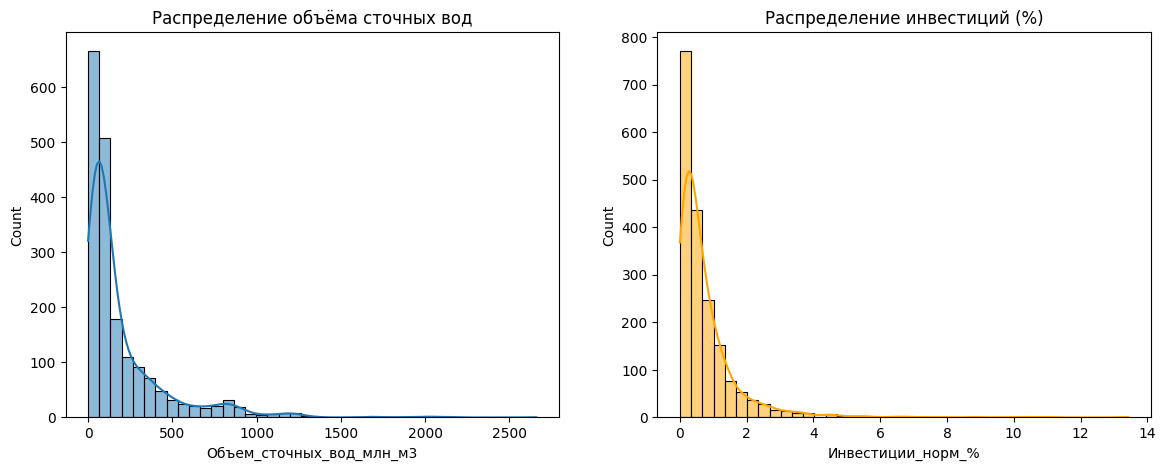

In [9]:
# 1. Гистограммы распределения
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.histplot(df['Объем_сточных_вод_млн_м3'], bins=40, kde=True)
plt.title("Распределение объёма сточных вод")
plt.subplot(1,2,2)
sns.histplot(df['Инвестиции_норм_%'], bins=40, kde=True, color='orange')
plt.title("Распределение инвестиций (%)")
plt.show()

99% регионов — низкие сбросы и инвестиции;

1% — экстремальные значения, на них всё держится.
Именно из-за них надо делать сегментированный анализ, иначе рискуем не увидеть настоящие связи между финансированием и снижением загрязнения.

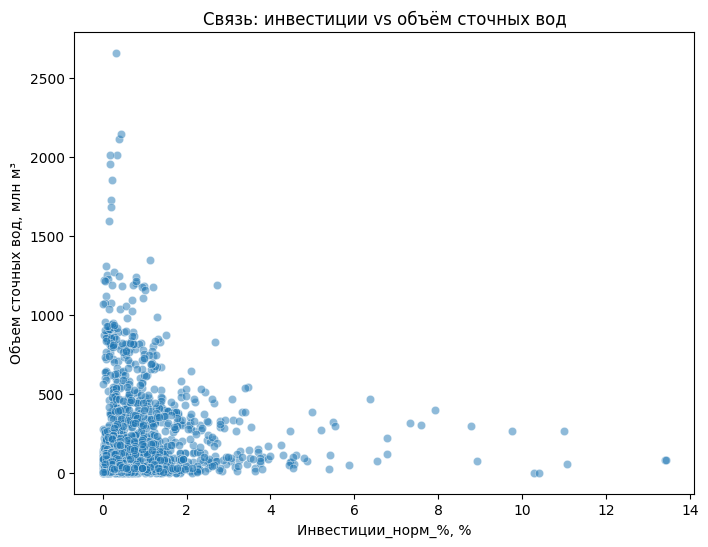

In [10]:
# 2. Scatter plot (общая взаимосвязь)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Инвестиции_норм_%', y='Объем_сточных_вод_млн_м3', data=df, alpha=0.5)
plt.title("Связь: инвестиции vs объём сточных вод")
plt.xlabel("Инвестиции_норм_%, %")
plt.ylabel("Объем сточных вод, млн м³")
plt.show()

Большинство регионов мало инвестируют и сбрасывают мало сточных вод.

Самые крупные загрязнители почти не тратят на экологию.

Высокие инвестиции не гарантируют низких сбросов, но таких случаев мало.

Корреляции между переменными нет: она либо очень слабая, либо скрыта другими факторами (размером региона, структурой экономики и пр.).

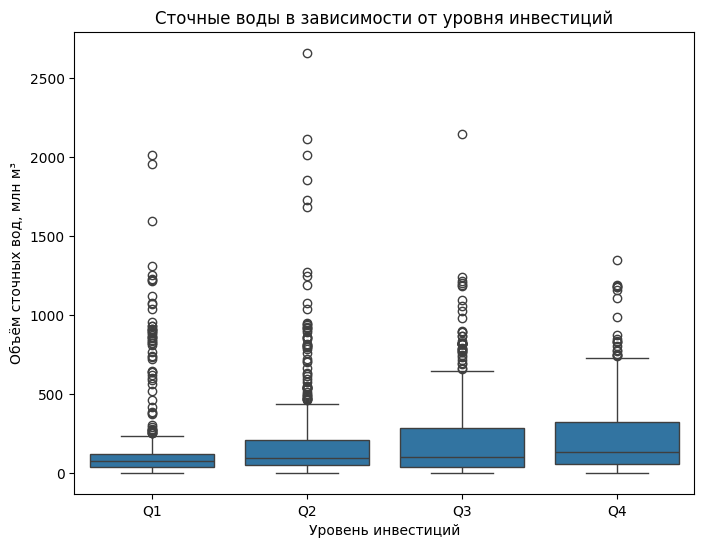

In [11]:
# 3. Boxplots по user-defined квартилям инвестиций
df['inv_quartile'] = pd.qcut(df['Инвестиции_норм_%'], 4, labels=['Q1','Q2','Q3','Q4'])
plt.figure(figsize=(8,6))
sns.boxplot(x='inv_quartile', y='Объем_сточных_вод_млн_м3', data=df)
plt.title("Сточные воды в зависимости от уровня инвестиций")
plt.xlabel("Уровень инвестиций")
plt.ylabel("Объём сточных вод, млн м³")
plt.show()

Если смотреть на все регионы вместе, то само по себе увеличение инвестиций не гарантирует снижения загрязнения.

Нужно искать другие объясняющие факторы или анализировать группы отдельно.

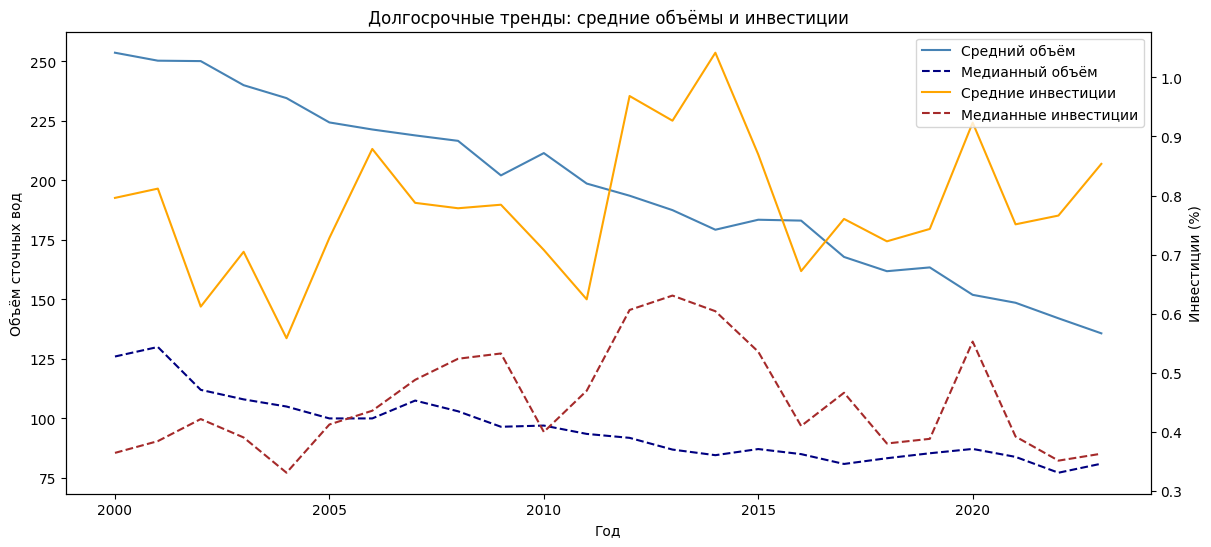

In [12]:
# 4. Долгосрочные тренды по годам
pivot = df.groupby('Год').agg({'Объем_сточных_вод_млн_м3':['mean', 'median'], 'Инвестиции_норм_%':['mean', 'median']})
pivot.columns = ['Объем_mean','Объем_median','Инв_mean','Инв_median']
pivot.reset_index(inplace=True)

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(pivot['Год'], pivot['Объем_mean'], label='Средний объём', color='steelblue')
ax1.plot(pivot['Год'], pivot['Объем_median'], label='Медианный объём', color='navy', linestyle='--')
ax2 = ax1.twinx()
ax2.plot(pivot['Год'], pivot['Инв_mean'], label='Средние инвестиции', color='orange')
ax2.plot(pivot['Год'], pivot['Инв_median'], label='Медианные инвестиции', color='brown', linestyle='--')
ax1.set_ylabel('Объём сточных вод')
ax2.set_ylabel('Инвестиции (%)')
ax1.set_xlabel('Год')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title("Долгосрочные тренды: средние объёмы и инвестиции")
plt.show()

Сбросы сточныхх вод снижается — это позитивный тренд.

Расходы на экологию не растут — эффект снижения сбросов случается без существенного увеличения финансирования.

Связь между ростом инвестиций и снижением сбросов по всей стране не подтверждается по этим данным.

Положительный результат по экологии есть, но он не связан напрямую с изменениями инвестиций на федеральном уровне.

Снижение загрязнения произошло, но скорее из-за сторонних факторов (законы, технологии, закрытие старых заводов и т.п.)

C:\Users\go130\AppData\Local\Temp\ipykernel_3084\1513922167.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()  # Убираем легенду
C:\Users\go130\AppData\Local\Temp\ipykernel_3084\1513922167.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()  # Убираем легенду


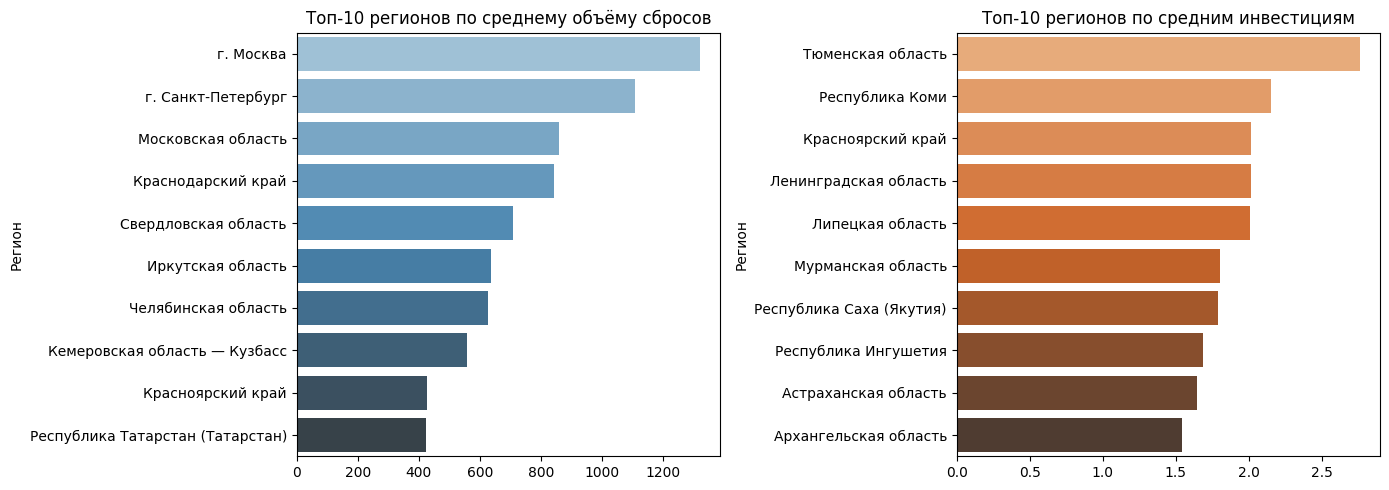

In [13]:
# 5. Топ-10 регионов по среднему объёму сбросов и инвестициям
top_vol = df.groupby('Регион')['Объем_сточных_вод_млн_м3'].mean().sort_values(ascending=False).head(10)
top_inv = df.groupby('Регион')['Инвестиции_норм_%'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.barplot(y=top_vol.index, x=top_vol.values, palette='Blues_d', hue=top_vol.index)
plt.title("Топ-10 регионов по среднему объёму сбросов")
plt.legend().remove()  # Убираем легенду

plt.subplot(1,2,2)
sns.barplot(y=top_inv.index, x=top_inv.values, palette='Oranges_d', hue=top_inv.index)
plt.title("Топ-10 регионов по средним инвестициям")
plt.legend().remove()  # Убираем легенду

plt.tight_layout()  
plt.show()

### Для презентации

In [20]:
final_df = df[[
    'Регион',
    'Год',
    'Объем_сточных_вод_млн_м3',
    'Инвестиции_норм_%',
    'ВРП_на_душу_руб',
    'Индексы_производства_продукции_СХ_%',
    'Доля_городского_населения_%',
    'Использование_свеж_воды_млн_м3',
    'Индекс_промыш_производства_%',
    'Числ_насел'  # если столбец так и называется
]].copy()

final_df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
0,Алтайский край,2000,31.0,0.377989,17660.5,122.0,52.8,569.0,109.2,2641.1
1,Алтайский край,2001,34.0,0.180408,23509.0,104.5,53.1,599.0,109.4,2621.1
2,Алтайский край,2002,36.0,0.092283,27991.2,103.1,53.2,563.0,100.1,2602.6
3,Алтайский край,2003,36.0,0.056477,34295.8,100.8,53.5,516.0,105.5,2572.0
4,Алтайский край,2004,36.0,0.033324,44934.9,99.5,53.7,488.0,102.6,2539.4


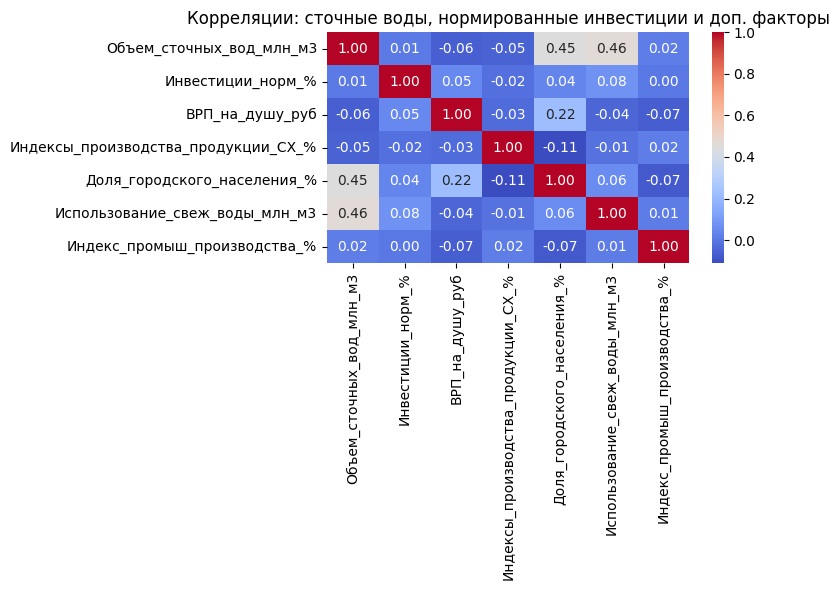

In [24]:
corr_cols = [
    'Объем_сточных_вод_млн_м3',
    'Инвестиции_норм_%',
    'ВРП_на_душу_руб',
    'Индексы_производства_продукции_СХ_%',
    'Доля_городского_населения_%',
    'Использование_свеж_воды_млн_м3',
    'Индекс_промыш_производства_%'
]

corr_df = final_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции: сточные воды, нормированные инвестиции и доп. факторы')
plt.tight_layout()
plt.show()

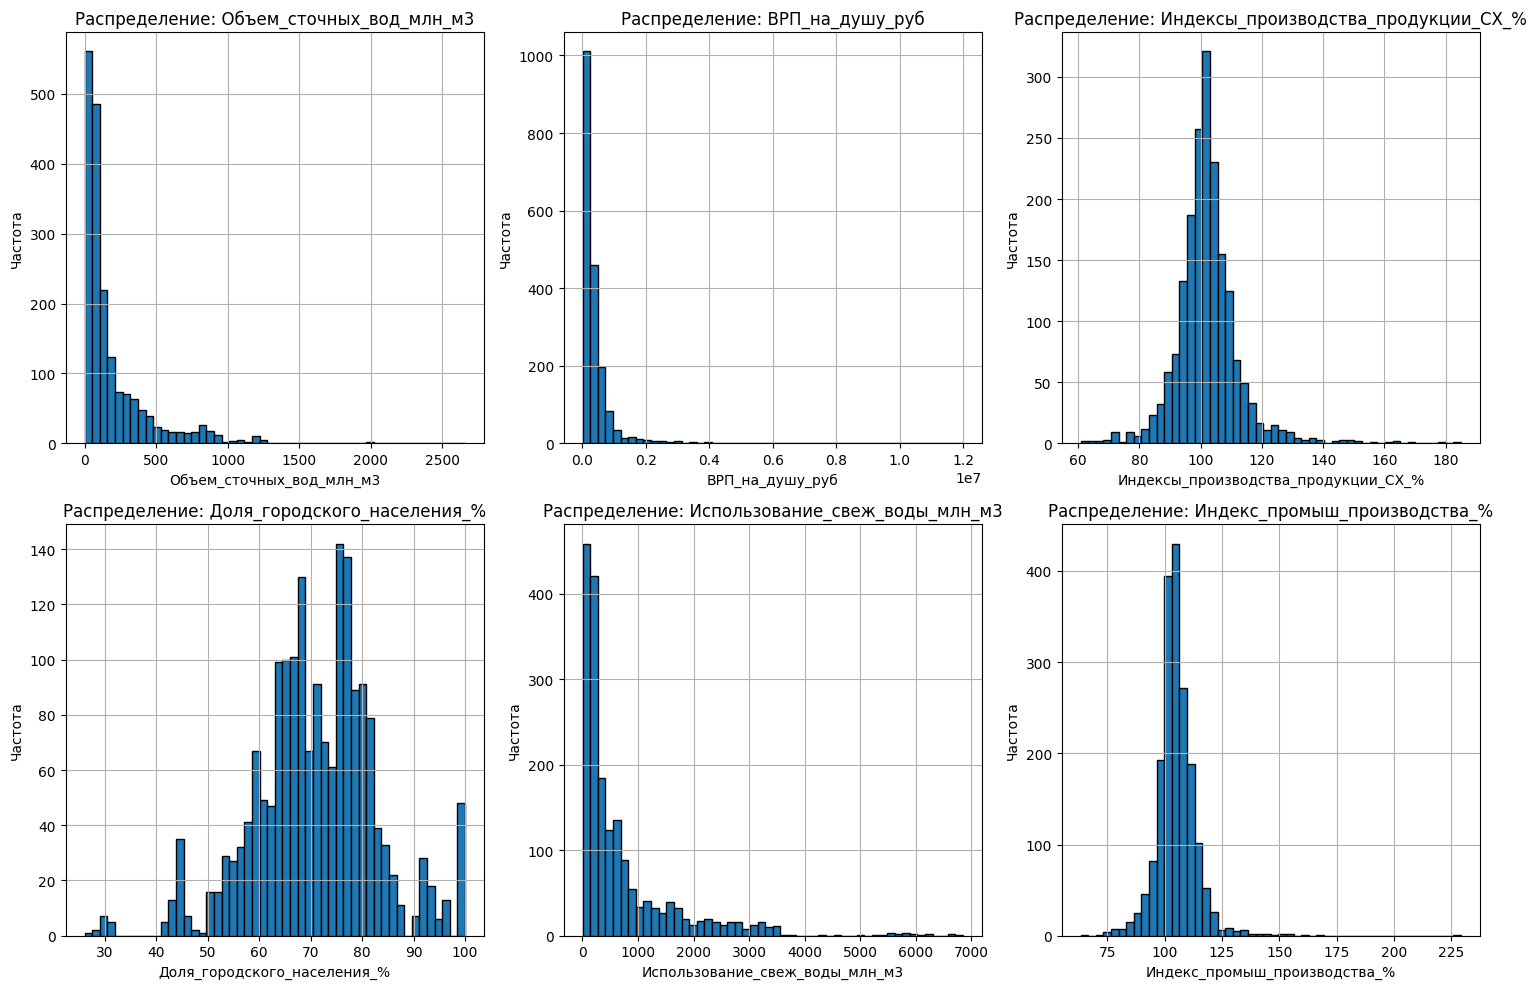

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Объем_сточных_вод_млн_м3', 'ВРП_на_душу_руб', 'Индексы_производства_продукции_СХ_%', 
            'Доля_городского_населения_%', 'Использование_свеж_воды_млн_м3', 'Индекс_промыш_производства_%']

for ax, feature in zip(axes.flatten(), features):
    df[feature].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'Распределение: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

### Подготовка данных

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# базовые признаки
features = [
    "Инвестиции_норм_%",
    "ВРП_на_душу_руб",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "Доля_городского_населения_%",
    "Числ_насел",
    "Использование_свеж_воды_млн_м3",
    "Год",
]

target = "Объем_сточных_вод_млн_м3"

X = df[features].copy()
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


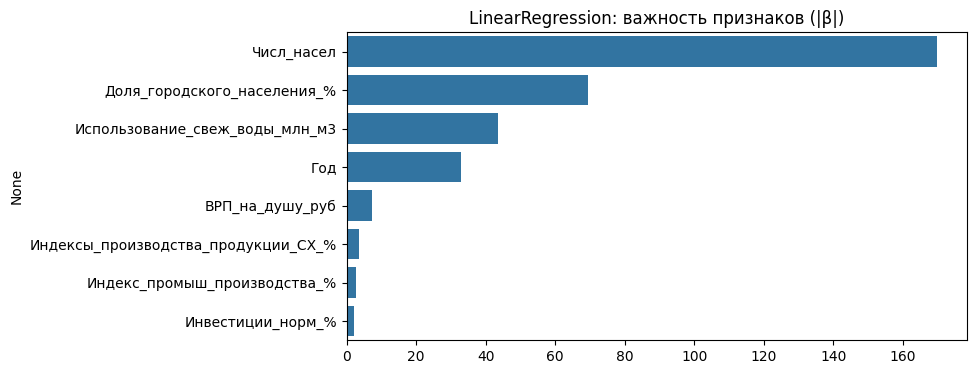

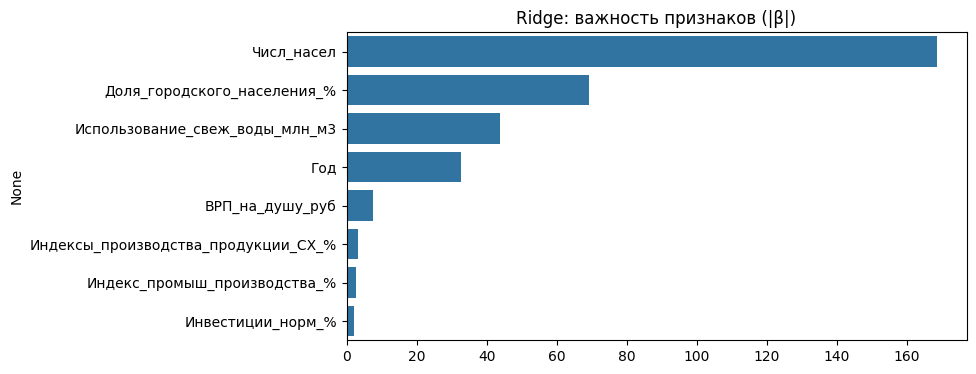

In [68]:
def plot_importances_bar(values, names, title):
    imp = pd.Series(values, index=names).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=imp.values, y=imp.index)
    plt.title(title)
    plt.show()

feature_names = X_train.columns  # имена признаков до масштабирования

# 1. "Важность" для LinearRegression: абсолютные стандартизованные коэффициенты
lin_coefs = np.abs(lin.coef_)  # модель обучена на X_train_scaled
plot_importances_bar(lin_coefs, feature_names, "LinearRegression: важность признаков (|β|)")

# 2. "Важность" для Ridge: аналогично по |коэффициентам|
ridge_coefs = np.abs(ridge.coef_)
plot_importances_bar(ridge_coefs, feature_names, "Ridge: важность признаков (|β|)")

1. Объём сточных вод в первую очередь определяется размером региона: чем больше население, тем больше сбросов.

C:\Users\go130\AppData\Local\Temp\ipykernel_3084\390859027.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\go130\AppData\Local\Temp\ipykernel_3084\390859027.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('01_parnaya_korrelyaciya.png', dpi=300, bbox_inches='tight', facecolor='white')
c:\Users\go130\anaconda3\envs\work\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


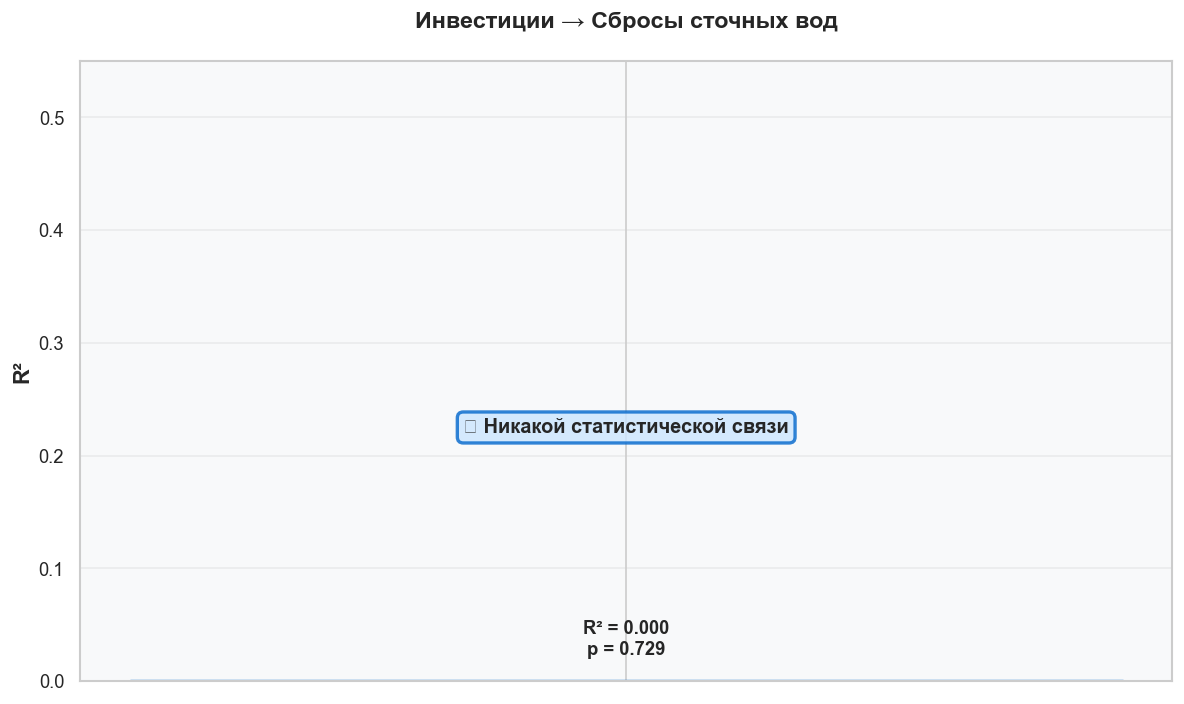

In [113]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Установи стиль и цвета
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

# Белая, синяя, голубая палитра
COLORS = {
    'primary': '#0066cc',      # глубокий синий
    'secondary': '#00a8e8',    # светлый голубой
    'accent': '#0099ff',       # яркий голубой
    'light': '#cce5ff',        # светлый голубой
    'gray': '#666666',         # серый для текста
    'success': '#00cc66',      # зелёный для значимых
    'danger': '#ff6666'        # красный для незначимых
}

plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

# ============================================================
# ДИАГРАММА 1: ПАРНАЯ КОРРЕЛЯЦИЯ
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Данные
models = ['']
r_squared = [0.000]
p_values = [0.729]

bars = ax.bar(models, r_squared, color=COLORS['danger'], width=0.5, edgecolor=COLORS['primary'], linewidth=2)

# Форматирование
ax.set_ylabel('R²', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.set_title('Инвестиции → Сбросы сточных вод', 
             fontsize=14, fontweight='bold', pad=20)

# Добавить значения на столбцы
for i, (bar, val) in enumerate(zip(bars, r_squared)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'R² = {val:.3f}\np = {p_values[i]:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Добавить текст-вывод
ax.text(0.5, 0.4, '❌ Никакой статистической связи', 
        ha='center', transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.8, edgecolor=COLORS['primary'], linewidth=2))

ax.set_ylim(0, 0.55)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('01_parnaya_korrelyaciya.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120


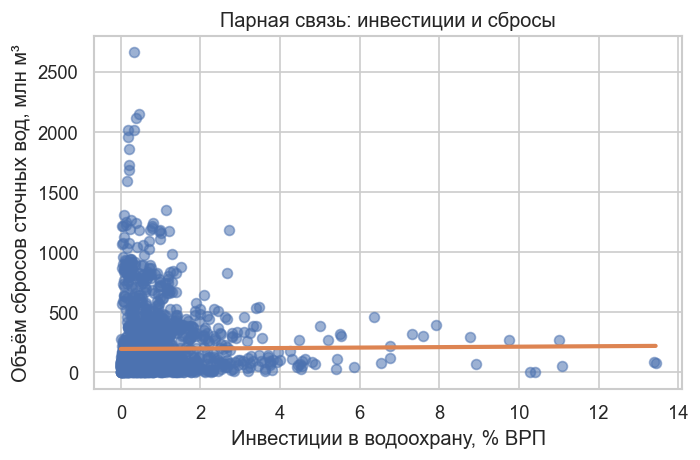

In [82]:
plt.figure(figsize=(6, 4))
sns.regplot(
    data=df,
    x="Инвестиции_норм_%",          # <-- реальные инвестиции
    y="Объем_сточных_вод_млн_м3",   # <-- реальные сбросы
    ci=None,
    scatter_kws={"alpha": 0.55, "s": 35, "color": "#4C72B0"},
    line_kws={"color": "#DD8452", "linewidth": 2.5}
)
plt.xlabel("Инвестиции в водоохрану, % ВРП")
plt.ylabel("Объём сбросов сточных вод, млн м³")
plt.title("Парная связь: инвестиции и сбросы")
plt.tight_layout()
plt.show()

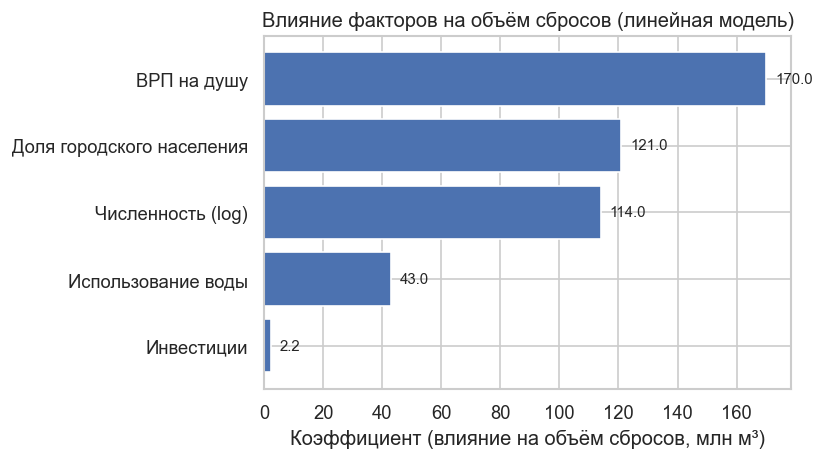

In [ ]:
import numpy as np

feature_names = [
    "Численность",
    "Инвестиции",
    "Индекс промышленного производства",
    "Использование воды",
    "Доля городского населения",
    "Инвестиции",
]

coef_values = np.array([170, 114, 43, 121, 2.2])

order = np.argsort(coef_values)

plt.figure(figsize=(7, 4))
bars = plt.barh(
    np.array(feature_names)[order],
    coef_values[order],
    color="#4C72B0"
)
plt.axvline(0, color="black", linewidth=1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + np.sign(width)*3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

plt.xlabel("Коэффициент (влияние на объём сбросов, млн м³)")
plt.title("Влияние факторов на объём сбросов (линейная модель)")
plt.tight_layout()
plt.show()


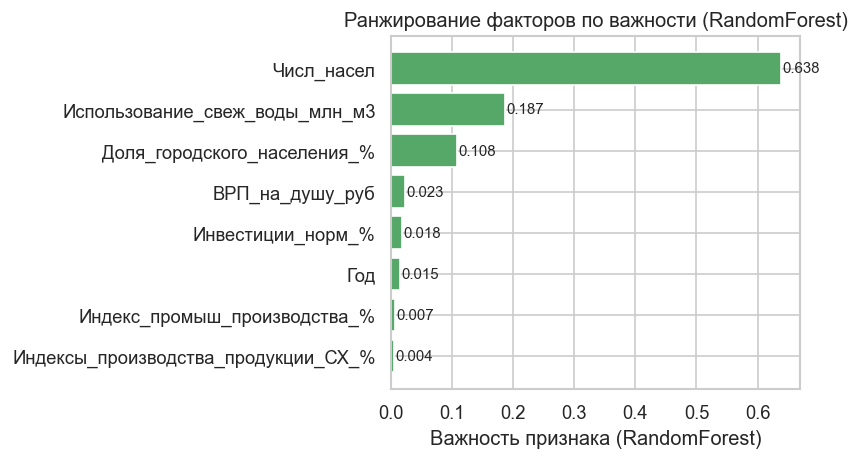

In [87]:
importances = rf.feature_importances_
indices = np.argsort(importances)

features2 = [
    "Инвестиции_норм_%",
    "ВРП_на_душу_руб",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "Доля_городского_населения_%",
    "Числ_насел",
    "Использование_свеж_воды_млн_м3",
    "Год",
]

plt.figure(figsize=(7, 4))
bars = plt.barh(
    np.array(features2)[indices],
    importances[indices],
    color="#55A868"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.xlabel("Важность признака (RandomForest)")
plt.title("Ранжирование факторов по важности (RandomForest)")
plt.tight_layout()
plt.show()


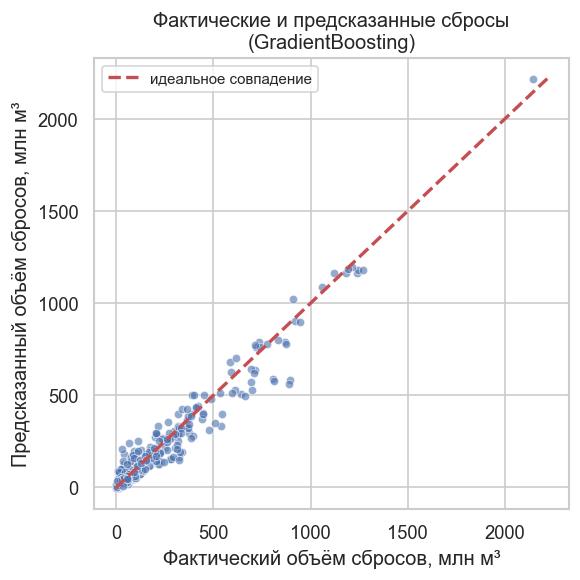

In [88]:
plt.figure(figsize=(5, 5))
plt.scatter(
    y_test,
    y_pred_gbr,              # предсказания GradientBoosting
    alpha=0.6,
    s=25,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5
)

min_val = min(y_test.min(), y_pred_gbr.min())
max_val = max(y_test.max(), y_pred_gbr.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="идеальное совпадение"
)

plt.xlabel("Фактический объём сбросов, млн м³")
plt.ylabel("Предсказанный объём сбросов, млн м³")
plt.title("Фактические и предсказанные сбросы\n(GradientBoosting)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


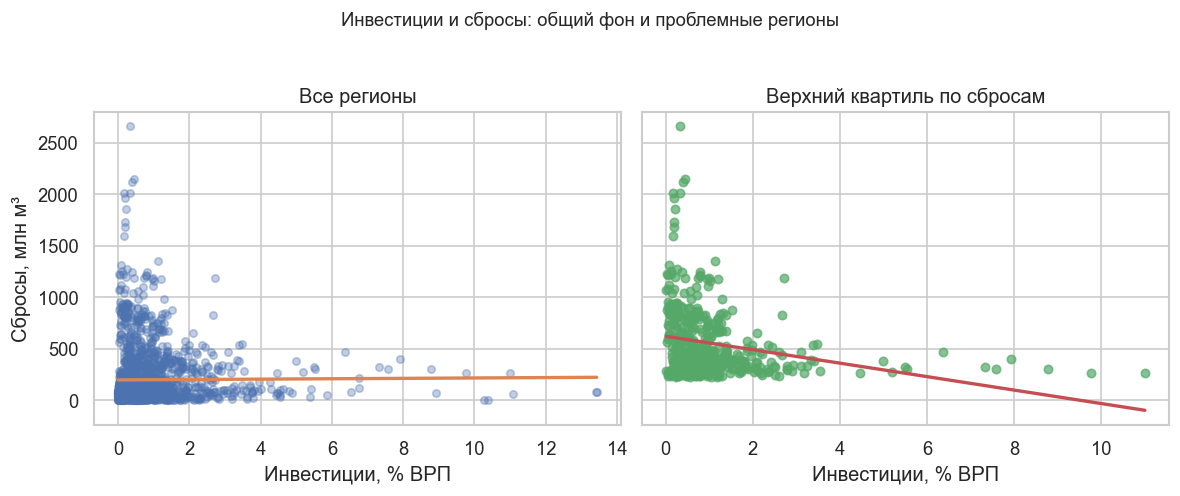

In [95]:
q75 = df["Объем_сточных_вод_млн_м3"].quantile(0.75)
df_top = df[df["Объем_сточных_вод_млн_м3"] >= q75]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.regplot(
    data=df,
    x="Инвестиции_норм_%",
    y="Объем_сточных_вод_млн_м3",
    ci=None,
    scatter_kws={"alpha": 0.35, "s": 20, "color": "#4C72B0"},
    line_kws={"color": "#DD8452", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Все регионы")
axes[0].set_xlabel("Инвестиции, % ВРП")
axes[0].set_ylabel("Сбросы, млн м³")

sns.regplot(
    data=df_top,
    x="Инвестиции_норм_%",
    y="Объем_сточных_вод_млн_м3",
    ci=None,
    scatter_kws={"alpha": 0.7, "s": 25, "color": "#55A868"},
    line_kws={"color": "#C44E52", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("Верхний квартиль по сбросам")
axes[1].set_xlabel("Инвестиции, % ВРП")
axes[1].set_ylabel("")

fig.suptitle("Инвестиции и сбросы: общий фон и проблемные регионы", y=1.03, fontsize=11)
plt.tight_layout()
plt.show()


C:\Users\go130\AppData\Local\Temp\ipykernel_3084\2003636100.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=r2_scores, palette="Blues")


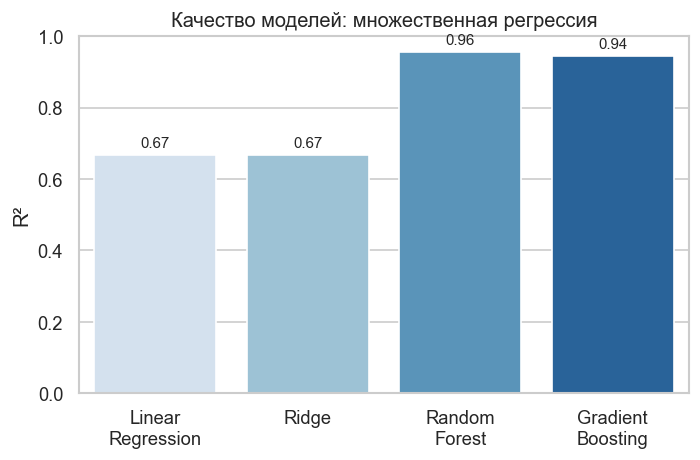

In [110]:
models = ["Linear\nRegression", "Ridge", "Random\nForest", "Gradient\nBoosting"]
r2_scores = [0.668, 0.667, 0.956, 0.945]  # подставь свои значения

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=models, y=r2_scores, palette="Blues")
for p, val in zip(ax.patches, r2_scores):
    ax.annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.ylim(0, 1)
plt.ylabel("R²")
plt.xlabel("")
plt.title("Качество моделей: множественная регрессия")
plt.tight_layout()
plt.show()


C:\Users\go130\AppData\Local\Temp\ipykernel_3084\3870777012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=r2_scores, palette="Blues")


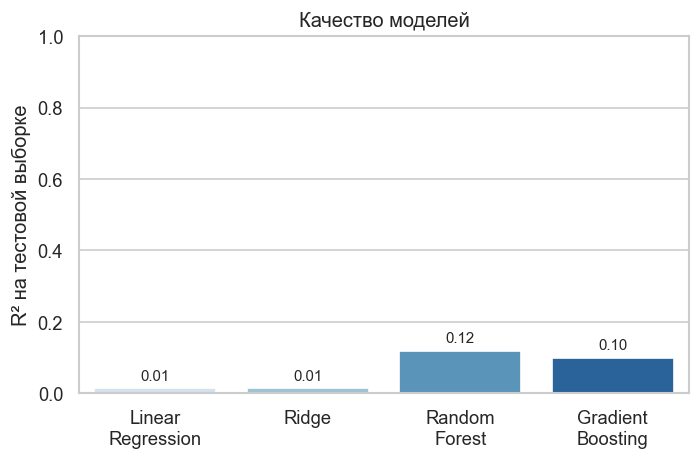

In [94]:
models = ["Linear\nRegression", "Ridge", "Random\nForest", "Gradient\nBoosting"]
r2_scores = [0.015, 0.015, 0.12, 0.1]  # подставь свои значения

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=models, y=r2_scores, palette="Blues")
for p, val in zip(ax.patches, r2_scores):
    ax.annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.ylim(0, 1)
plt.ylabel("R² на тестовой выборке")
plt.xlabel("")
plt.title("Качество моделей")
plt.tight_layout()
plt.show()


C:\Users\go130\AppData\Local\Temp\ipykernel_3084\1469926381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models_small, y=r2_small, palette="Reds")


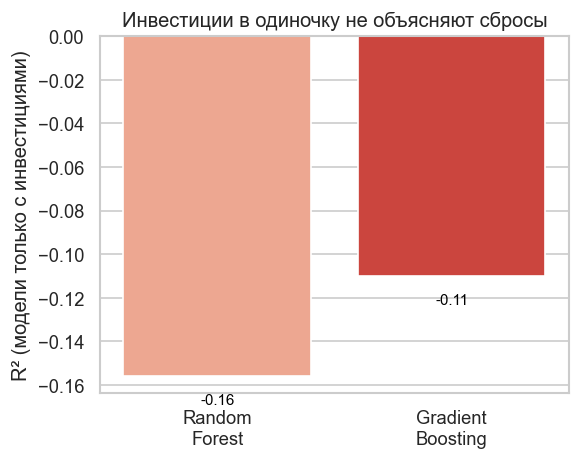

In [ ]:
models_small = ["Random\nForest", "Gradient\nBoosting"]
r2_small = [-0.156, -0.11]

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=models_small, y=r2_small, palette="Reds")
plt.axhline(0, color="black", linewidth=1)

for p, val in zip(ax.patches, r2_small):
    ax.annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom" if val > 0 else "top",
        fontsize=9,
        xytext=(0, 3 if val > 0 else -10),
        textcoords="offset points",
        color="black"
    )

plt.ylabel("R² (модели только с инвестициями)")
plt.xlabel("")
plt.title("Инвестиции в одиночку не объясняют сбросы")
plt.tight_layout()
plt.show()


C:\Users\go130\AppData\Local\Temp\ipykernel_3084\938922435.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=r2_scores, palette="Blues")


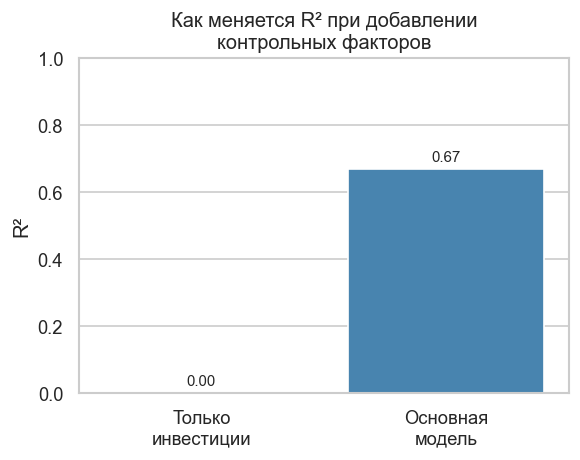

In [103]:
# R² парной регрессии "инвестиции → сбросы"
r2_pair = 0.000      # из первой проверки

# R² основной множественной модели с контролями
r2_multi = 0.670     # из вывода OLS основной модели

models = ["Только\nинвестиции", "Основная\nмодель"]
r2_scores = [r2_pair, r2_multi]

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=models, y=r2_scores, palette="Blues")

for p, val in zip(ax.patches, r2_scores):
    ax.annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.ylim(0, 1)
plt.ylabel("R²")
plt.xlabel("")
plt.title("Как меняется R² при добавлении\nконтрольных факторов")
plt.tight_layout()
plt.show()


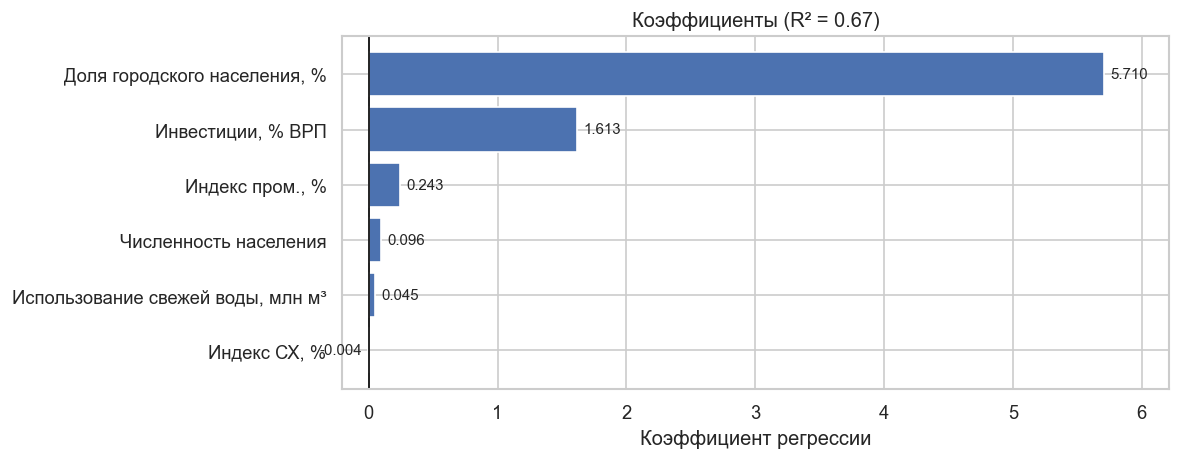

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120

feature_names = [
    "Доля городского населения, %",
    "Инвестиции, % ВРП",
    "Индекс пром., %",
    "Численность населения",
    "Использование свежей воды, млн м³",
    "Индекс СХ, %",
]

betas = np.array([
    5.7101,   # Доля_городского_населения_%
    1.6132,   # Инвестиции_норм_%
    0.2427,   # Индекс_промыш_производства_%
    0.0961,   # Числ_насел
    0.0451,   # Использование_свеж_воды_млн_м3
    -0.0040,  # Индексы_производства_продукции_СХ_%
])

# сортировка по величине коэффициента (по убыванию)
order = np.argsort(betas)

plt.figure(figsize=(10, 4))
bars = plt.barh(
    np.array(feature_names)[order],
    betas[order],
    color="#4C72B0"
)
plt.axvline(0, color="black", linewidth=1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05 * np.sign(width),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

plt.xlabel("Коэффициент регрессии")
plt.title("Коэффициенты (R² = 0.67)")
plt.xlim(min(-0.2, betas.min() - 0.2), betas.max() + 0.5)
plt.tight_layout()
plt.show()


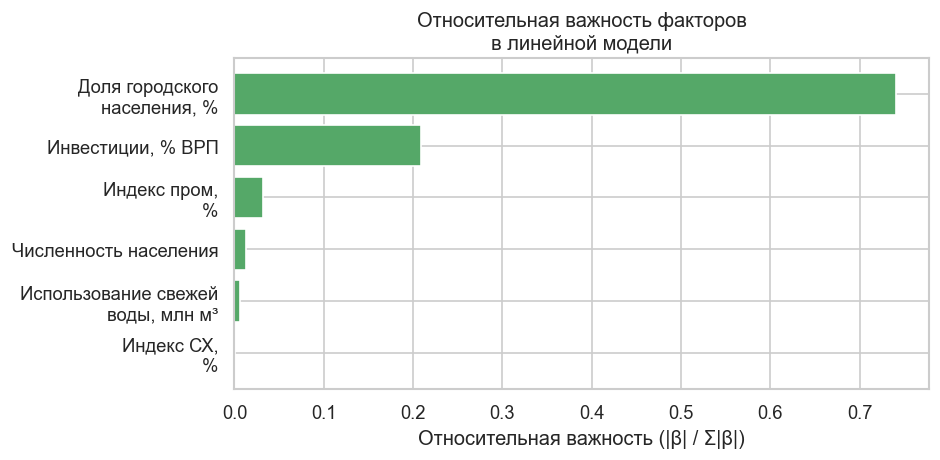

In [123]:
importance_abs = np.abs(betas)
order2 = np.argsort(importance_abs)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    np.array(feature_names)[order2],
    importance_abs[order2] / importance_abs.sum(),
    color="#55A868"
)
plt.xlabel("Относительная важность (|β| / Σ|β|)")
plt.title("Относительная важность факторов\nв линейной модели")
plt.tight_layout()
plt.show()


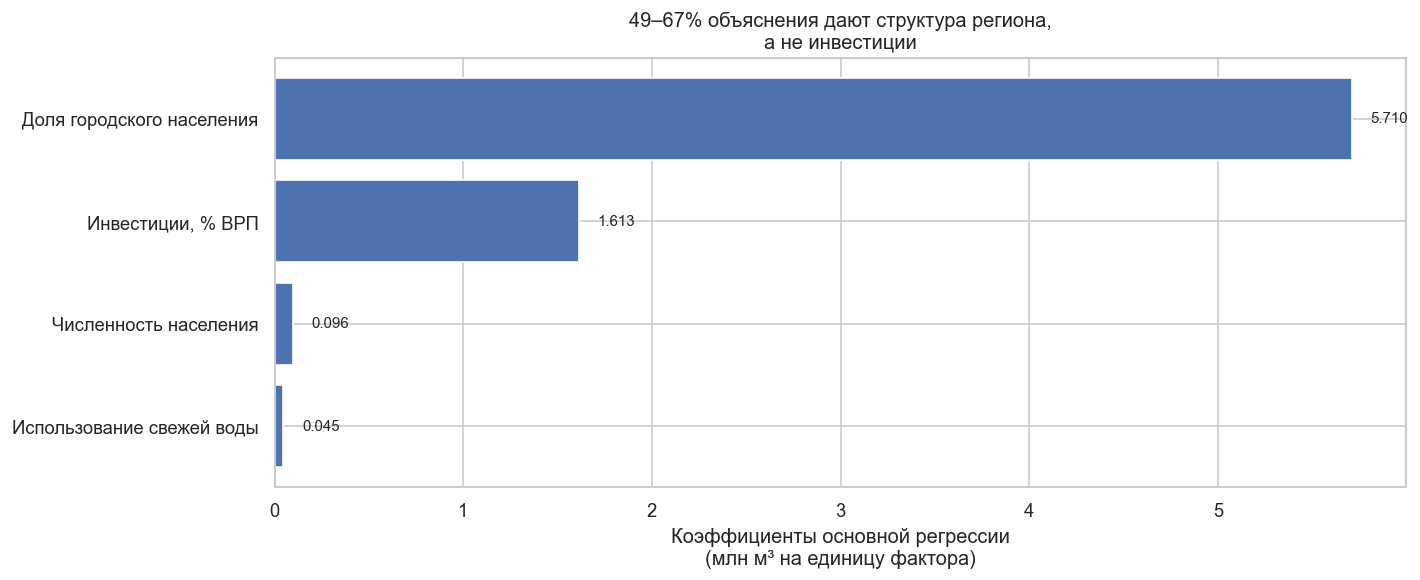

In [120]:
feature_names_core = [
    "Инвестиции, % ВРП",
    "Численность населения",
    "Доля городского населения",
    "Использование свежей воды",
]

betas_core = np.array([
    1.6132,   # инвестиции
    0.0961,   # численность
    5.7101,   # доля городского
    0.0451,   # вода
])

order_core = np.argsort(betas_core)

plt.figure(figsize=(12, 5))
bars_core = plt.barh(
    np.array(feature_names_core)[order_core],
    betas_core[order_core],
    color="#4C72B0"
)
plt.axvline(0, color="black", linewidth=1)

for bar in bars_core:
    width = bar.get_width()
    plt.text(
        width + np.sign(width)*0.1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

plt.xlabel("Коэффициенты основной регрессии\n(млн м³ на единицу фактора)")
plt.title("49–67% объяснения дают структура региона,\nа не инвестиции")
plt.tight_layout()
plt.show()


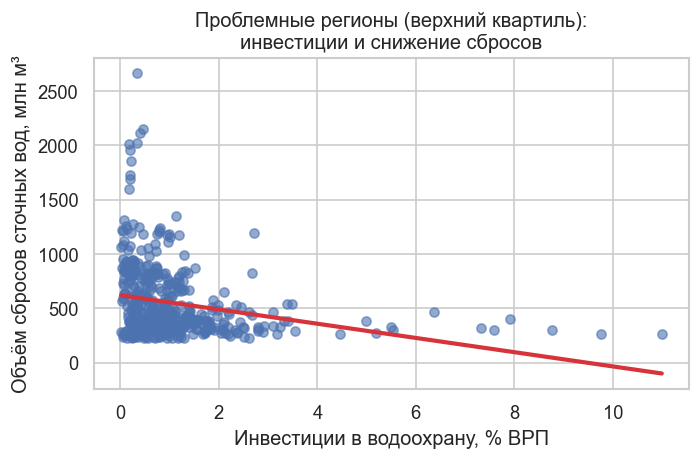

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120

# df_top — данные только по верхнему квартилю (471 наблюдение)
plt.figure(figsize=(6, 4))
sns.regplot(
    data=df_top,
    x="Инвестиции_норм_%",
    y="Объем_сточных_вод_млн_м3",
    ci=None,
    scatter_kws={"alpha": 0.6, "s": 30, "color": "#4C72B0"},
    line_kws={"color": "#D6343A", "linewidth": 2.5}
)
plt.xlabel("Инвестиции в водоохрану, % ВРП")
plt.ylabel("Объём сбросов сточных вод, млн м³")
plt.title("Проблемные регионы (верхний квартиль):\nинвестиции и снижение сбросов")
plt.tight_layout()
plt.show()


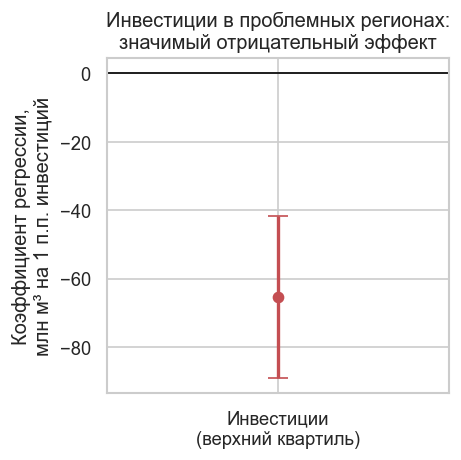

In [108]:
import numpy as np

coef = -65.4070
se = 12.075

plt.figure(figsize=(4, 4))
x = ["Инвестиции\n(верхний квартиль)"]
y = [coef]
yerr = [1.96 * se]   # 95%-й доверительный интервал

plt.errorbar(
    x=x,
    y=y,
    yerr=yerr,
    fmt="o",
    color="#C44E52",
    ecolor="#C44E52",
    elinewidth=2,
    capsize=6
)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Коэффициент регрессии,\nмлн м³ на 1 п.п. инвестиций")
plt.title("Инвестиции в проблемных регионах:\nзначимый отрицательный эффект")
plt.tight_layout()
plt.show()


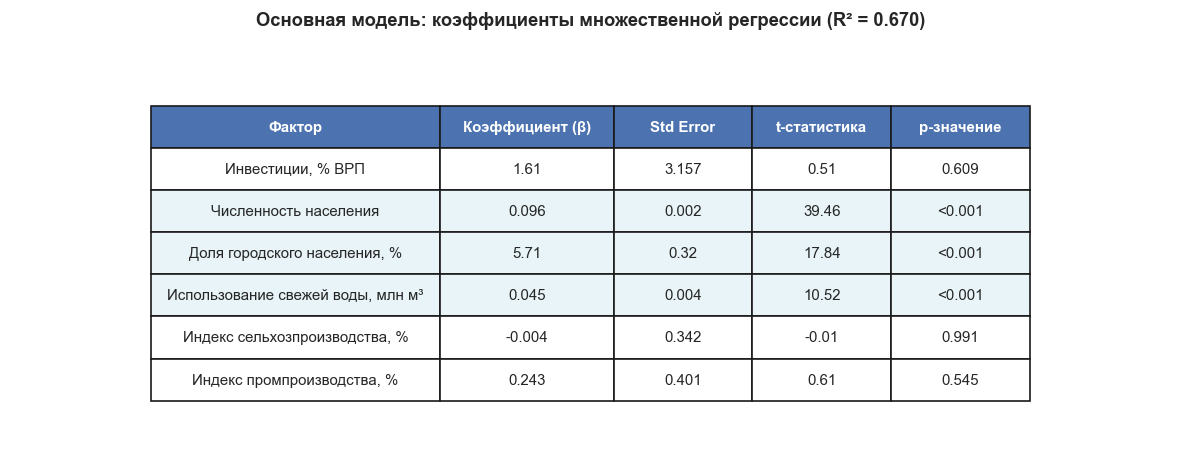

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Данные из OLS регрессии
data = {
    "Фактор": [
        "Инвестиции, % ВРП",
        "Численность населения",
        "Доля городского населения, %",
        "Использование свежей воды, млн м³",
        "Индекс сельхозпроизводства, %",
        "Индекс промпроизводства, %"
    ],
    "Коэффициент (β)": [1.61, 0.096, 5.71, 0.045, -0.004, 0.243],
    "Std Error": [3.157, 0.002, 0.320, 0.004, 0.342, 0.401],
    "t-статистика": [0.51, 39.46, 17.84, 10.52, -0.01, 0.61],
    "p-значение": [0.609, "<0.001", "<0.001", "<0.001", 0.991, 0.545]
}

df = pd.DataFrame(data)

# Создаём фигуру и скрываем оси
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Таблица
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.25, 0.15, 0.12, 0.12, 0.12]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Оформление header
for i in range(len(df.columns)):
    table[(0, i)].set_facecolor("#4C72B0")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Раскраска значимых строк (p < 0.05)
for i in range(1, len(df) + 1):
    if df.iloc[i-1]["p-значение"] == "<0.001" or float(df.iloc[i-1]["p-значение"]) < 0.05:
        for j in range(len(df.columns)):
            table[(i, j)].set_facecolor("#E8F4F8")
    else:
        for j in range(len(df.columns)):
            table[(i, j)].set_facecolor("#FFFFFF")

plt.title("Основная модель: коэффициенты множественной регрессии (R² = 0.670)", 
          fontsize=11, weight="bold", pad=20)
plt.tight_layout()
plt.show()


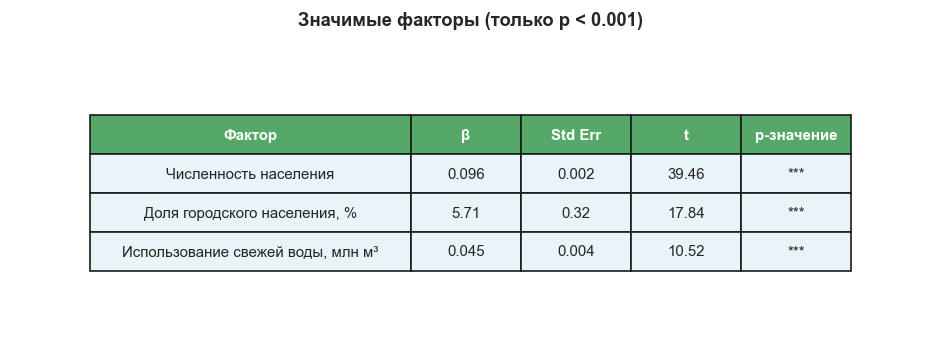

In [ ]:
# Если слайд тесный, можно показать только значимые (p < 0.05)
data_sig = {
    "Фактор": [
        "Численность населения",
        "Доля городского населения, %",
        "Использование свежей воды, млн м³",
    ],
    "β": [0.096, 5.71, 0.045],
    "Std Err": [0.002, 0.320, 0.004],
    "t": [39.46, 17.84, 10.52],
    "p-значение": ["***", "***", "***"] 
}

df_sig = pd.DataFrame(data_sig)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df_sig.values,
    colLabels=df_sig.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.35, 0.12, 0.12, 0.12, 0.12]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Header
for i in range(len(df_sig.columns)):
    table[(0, i)].set_facecolor("#55A868")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Все строки получают светлый фон
for i in range(1, len(df_sig) + 1):
    for j in range(len(df_sig.columns)):
        table[(i, j)].set_facecolor("#E8F4F8")

plt.title("Значимые факторы (только p < 0.001)", fontsize=11, weight="bold", pad=20)
plt.tight_layout()
plt.show()
